In [70]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from pickle import dump
from sklearn.cluster import KMeans
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns


Carga de datos

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv")

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Vamos a hacer un dataframe solo con las columnas que nos interesan


In [3]:
clean_df =  df[["MedInc", "Latitude", "Longitude"]]
clean_df.head()

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25


Vamos a escalar los datos para facilitar al modelo. Usaremos RobustScaler en este caso

In [5]:
robust_scaler = RobustScaler()

robust_scaler_train = robust_scaler.fit_transform(clean_df)

X = pd.DataFrame(robust_scaler_train, 
                             columns=clean_df.columns,
                             index=clean_df.index)

X

,MedInc,Latitude,Longitude
0,2.197582,0.957672,-0.986807
1,2.186664,0.952381,-0.984169
2,1.707732,0.949735,-0.989446
3,0.967177,0.949735,-0.992084
4,0.142854,0.949735,-0.992084
...,...,...,...
20635,-0.905796,1.380952,-0.686016
20636,-0.448655,1.383598,-0.717678
20637,-0.841709,1.367725,-0.720317
20638,-0.765007,1.367725,-0.746702


Vamos a hacer K-MEAN y le añadiremos la columna de cluster indicando en que cluster estas cada vivienda

In [13]:
model = KMeans(n_clusters=6, random_state=14)
model.fit(X)

,n_clusters,6
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,14
,copy_x,True
,algorithm,'lloyd'


In [34]:
X['cluster'] = model.labels_

X

,MedInc,Latitude,Longitude,cluster
0,2.197582,0.957672,-0.986807,3
1,2.186664,0.952381,-0.984169,3
2,1.707732,0.949735,-0.989446,1
3,0.967177,0.949735,-0.992084,1
4,0.142854,0.949735,-0.992084,5
...,...,...,...,...
20635,-0.905796,1.380952,-0.686016,5
20636,-0.448655,1.383598,-0.717678,5
20637,-0.841709,1.367725,-0.720317,5
20638,-0.765007,1.367725,-0.746702,5


Vamos a graficar los clusteres para ver los resultados

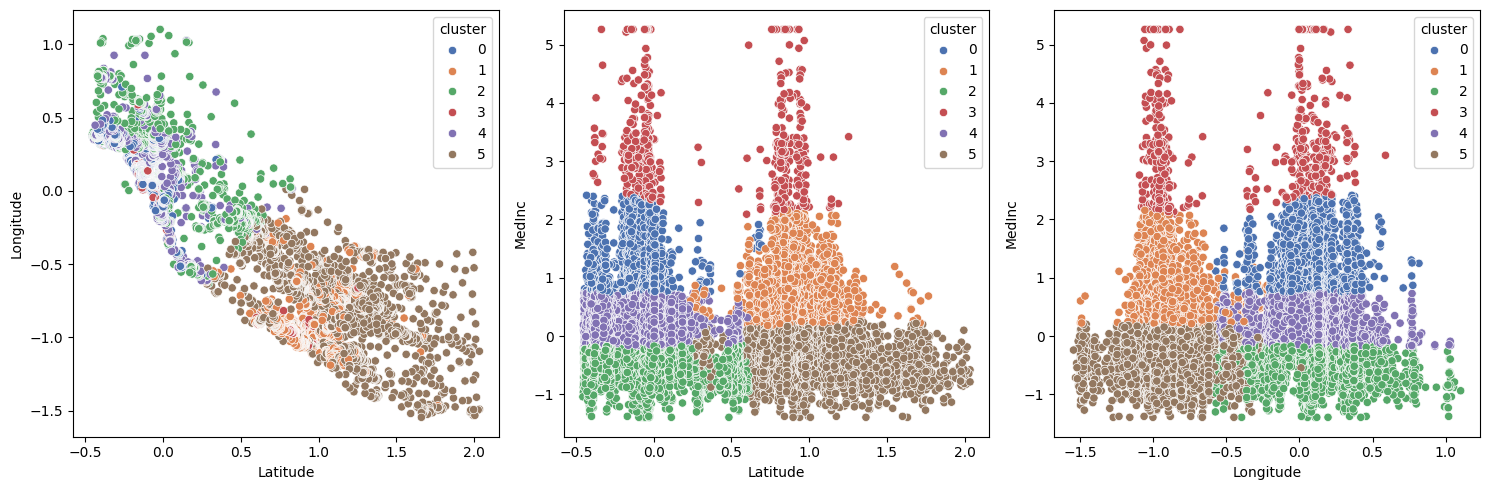

In [43]:
fig, axis = plt.subplots(1, 3, figsize = (15, 5))

sns.scatterplot(ax = axis[0], data = X, x = "Latitude", y = "Longitude", hue = "cluster", palette = "deep")
sns.scatterplot(ax = axis[1], data = X, x = "Latitude", y = "MedInc", hue = "cluster", palette = "deep")
sns.scatterplot(ax = axis[2], data = X, x = "Longitude", y = "MedInc", hue = "cluster", palette = "deep")
plt.tight_layout()

plt.show()


Ahora haremos un modelo supervisado para probar nuestros resultados

Haremos el split para conseguir X y Y segun nuestro Kmeans

In [36]:

Z = X[['Latitude', 'Longitude', 'MedInc']]


y = X['cluster']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(Z, y, test_size=0.2, random_state=14)

In [39]:
clf = RandomForestClassifier(random_state=14)
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [73]:
y_pred = clf.predict(X_test)


accuracy_score(y_pred, y_test)

0.9949127906976745

In [74]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       429
           1       0.99      0.99      0.99       648
           2       0.99      1.00      1.00       976
           3       0.99      0.99      0.99       107
           4       1.00      1.00      1.00       945
           5       1.00      0.99      0.99      1023

    accuracy                           0.99      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       0.99      0.99      0.99      4128



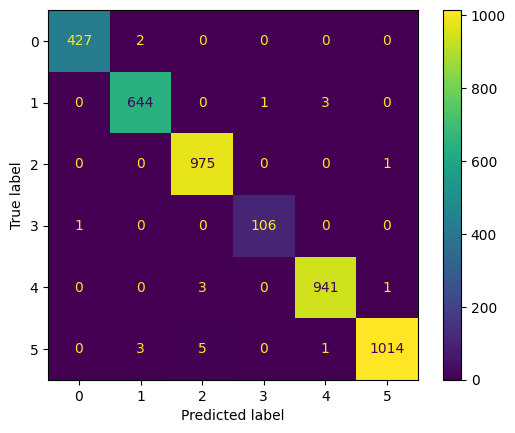

In [75]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [76]:
with open('modelo_k_means.pkl', 'wb') as file:
    dump(model, file)

with open('modelo_kmeans_randomforest.pkl', 'wb') as file:
    dump(clf, file)

# Conclusion
Gracias a kmeans hemos podido sacar un modelo de random forest con una precision del 0.99

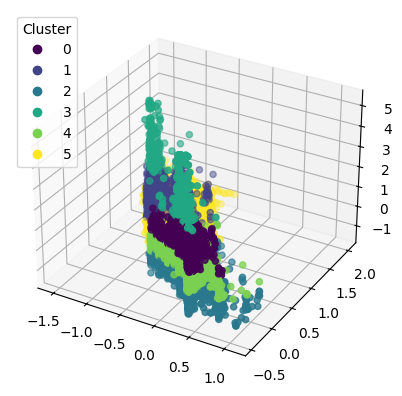

In [ ]:
plot = plt.figure().add_subplot(projection='3d')
scatter = plot.scatter(X['Longitude'], X['Latitude'], X['MedInc'], c=X['cluster'])
legend = plot.legend(*scatter.legend_elements(), title='Cluster', loc='upper left')
plt.show()